## Tạo Synthetic Data

In [1]:
import sys
import os

# Thêm thư mục gốc vào path để có thể import từ thư mục 'src'
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

from src.model import hierarchical_kmeans_resampling
from src.metrics import calculate_kl_divergence # Hàm bạn đã chép vào metrics.py

In [2]:
from sklearn.datasets import make_blobs

# Cố định random_state để tái hiện kết quả
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def generate_synthetic_data(n_points=9000):
    """
    Mục đích: Tạo dữ liệu giả lập 2D kết hợp giữa các cụm Gauss và phân phối đều.
    Mô phỏng hiện tượng dữ liệu thực tế có những khái niệm phổ biến (mật độ cao) 
    và các khái niệm hiếm (mật độ thấp).

    Tham số:
    - n_points (int): Tổng số lượng điểm dữ liệu cần tạo. Mặc định là 9000.

    Giá trị trả về:
    - X (numpy.ndarray): Mảng 2 chiều kích thước (n_points, 2) chứa tọa độ các điểm.Tạo dữ liệu mô phỏng theo Mục 4.1 của bài báo.
    Kết hợp giữa các cụm Gauss mật độ cao và phân phối đều.
    """
    
    # 1. Tạo 3 cụm Gauss (chiếm khoảng 60% dữ liệu)
    n_gaussians = int(n_points * 0.6)
    centers = [[-1.5, -1.5], [1, 1], [-1, 1]]
    X_gauss, _ = make_blobs(n_samples=n_gaussians, centers=centers, 
                            cluster_std=0.4, random_state=RANDOM_STATE)
    
    # 2. Tạo dữ liệu phân phối đều (chiếm 40% còn lại) làm nền
    n_uniform = n_points - n_gaussians
    X_uniform = np.random.uniform(-3, 3, (n_uniform, 2))
    
    # Hợp nhất dữ liệu
    X = np.vstack([X_gauss, X_uniform])
    return X

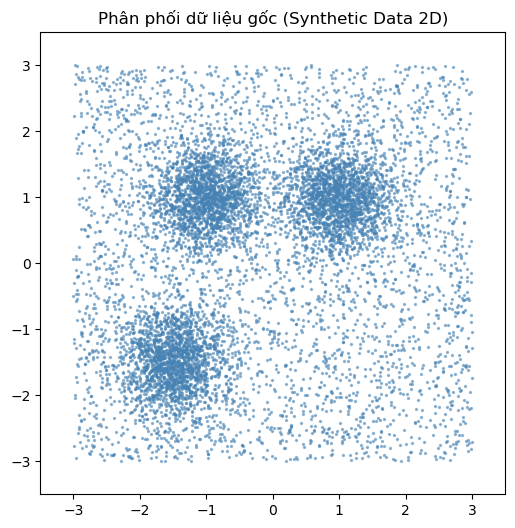

In [3]:
# Thực thi
X = generate_synthetic_data()

# Vẽ biểu đồ quan sát
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=2, alpha=0.5, color='steelblue')
plt.title("Phân phối dữ liệu gốc (Synthetic Data 2D)")
plt.xlim(-3.5, 3.5)
plt.ylim(-3.5, 3.5)
plt.show()

## Cài đặt thuật toán Hierarchical K-means (Algorithm 1)

In [4]:
# Chạy Standard K-means (Baseline)
k_final = 300
kmeans_std = KMeans(n_clusters=k_final, init='k-means++', n_init=1, random_state=42)
kmeans_std.fit(X)
centroids_std = kmeans_std.cluster_centers_

# Dùng k giảm dần để ép các centroid phân bố đều
k_list = [1000, 600, 300] 
results = hierarchical_kmeans_resampling(X, k_list=k_list, T=3, m=10, r_t=5)

centroids_hkm = results["final_centroids"]

--- Level 1/3 ---
--- Level 2/3 ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

--- Level 3/3 ---


## Vẽ biểu đồ so sánh (Qualitative Evaluation)

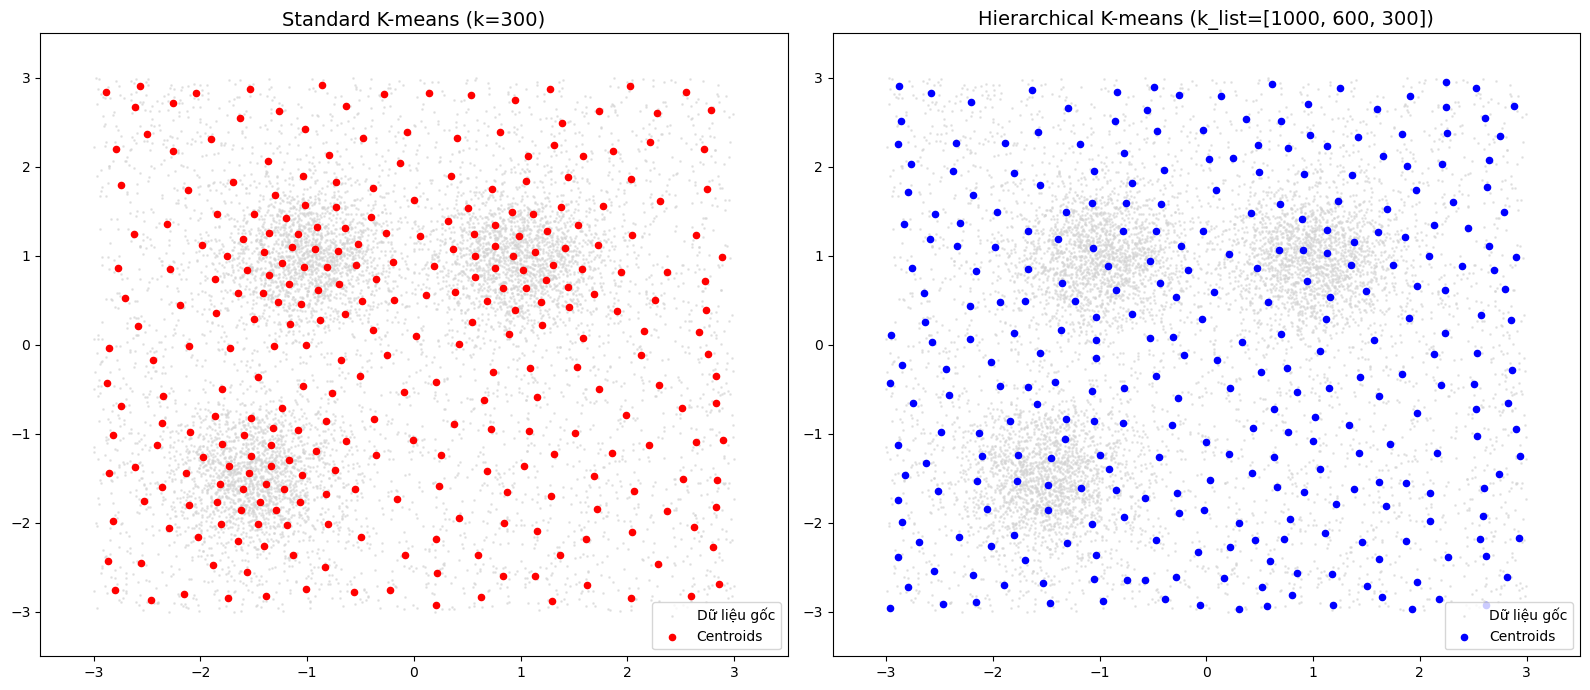

In [5]:
import matplotlib.pyplot as plt

# Vẽ Scatter Plot so sánh
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot Standard K-means
ax1.scatter(X[:, 0], X[:, 1], s=1, color='lightgray', alpha=0.5, label='Dữ liệu gốc')
ax1.scatter(centroids_std[:, 0], centroids_std[:, 1], s=20, color='red', marker='o', label='Centroids')
ax1.set_title(f"Standard K-means (k={k_final})", fontsize=14)
ax1.set_xlim(-3.5, 3.5); ax1.set_ylim(-3.5, 3.5)
ax1.legend()

# Plot Hierarchical K-means
ax2.scatter(X[:, 0], X[:, 1], s=1, color='lightgray', alpha=0.5, label='Dữ liệu gốc')
ax2.scatter(centroids_hkm[:, 0], centroids_hkm[:, 1], s=20, color='blue', marker='o', label='Centroids')
ax2.set_title(f"Hierarchical K-means (k_list={k_list})", fontsize=14)
ax2.set_xlim(-3.5, 3.5); ax2.set_ylim(-3.5, 3.5)
ax2.legend()

plt.tight_layout()
plt.show()

## Tính toán KL-Divergence (Quantitative Evaluation)

In [6]:
kl_std = calculate_kl_divergence(centroids_std)
kl_hkm = calculate_kl_divergence(centroids_hkm)

print(f"{'Phương pháp':<30} | {'KL-Divergence':<15}")
print("-" * 50)
print(f"{'Standard K-means':<30} | {kl_std:.6f}")
print(f"{'Hierarchical K-means':<30} | {kl_hkm:.6f}")
print("-" * 50)
improvement = (kl_std - kl_hkm) / kl_std * 100
print(f"Mức độ cải thiện (flattening): {improvement:.2f}%")

Phương pháp                    | KL-Divergence  
--------------------------------------------------
Standard K-means               | 0.083618
Hierarchical K-means           | 0.031477
--------------------------------------------------
Mức độ cải thiện (flattening): 62.36%
